In [41]:
#Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
#Import Data

In [18]:
df = pd.read_csv('car_price.csv')
df

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats
...,...,...,...,...,...,...,...,...,...,...
5507,5507,BMW X1 sDrive 20d xLine,28.90 Lakh,"45,000 kms",Diesel,Automatic,1st Owner,2018,2995 cc,7 Seats
5508,5508,BMW M Series M4 Coupe,64.90 Lakh,"29,000 kms",Petrol,Automatic,2nd Owner,2015,1968 cc,5 Seats
5509,5509,Jaguar XF 2.2 Litre Luxury,13.75 Lakh,"90,000 kms",Diesel,Automatic,2nd Owner,2013,2755 cc,5 Seats
5510,5510,BMW 7 Series 730Ld,29.90 Lakh,"79,000 kms",Diesel,Automatic,3rd Owner,2015,2967 cc,6 Seats


In [43]:
#Checking for null values

In [19]:
df.isnull().sum()

Unnamed: 0             0
car_name               0
car_prices_in_rupee    0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
manufacture            0
engine                 0
Seats                  0
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5512 non-null   int64 
 1   car_name             5512 non-null   object
 2   car_prices_in_rupee  5512 non-null   object
 3   kms_driven           5512 non-null   object
 4   fuel_type            5512 non-null   object
 5   transmission         5512 non-null   object
 6   ownership            5512 non-null   object
 7   manufacture          5512 non-null   int64 
 8   engine               5512 non-null   object
 9   Seats                5512 non-null   object
dtypes: int64(2), object(8)
memory usage: 430.8+ KB


In [44]:
#Converting to consistent currency

In [21]:
def convert_price_to_rupees(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip().replace(',', '')
    
    if 'crore' in value.lower():
        num = value.lower().replace('crore', '').strip()
        return pd.to_numeric(num, errors='coerce') * 1e7
    
    elif 'lakh' in value.lower():
        num = value.lower().replace('lakh', '').strip()
        return pd.to_numeric(num, errors='coerce') * 1e5
    
    else:
        return pd.to_numeric(value, errors='coerce')

df['car_prices_in_rupee'] = df['car_prices_in_rupee'].apply(convert_price_to_rupees)


In [45]:
#Removing text values, changing to numerical columns.

In [22]:
# kms driven
df['kms_driven'] = (
    df['kms_driven']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)', expand=False)
)
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

# seats
df['Seats'] = (
    df['Seats']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)
df['Seats'] = pd.to_numeric(df['Seats'], errors='coerce')

# engine
df['engine'] = (
    df['engine']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'(\d+)', expand=False)
)
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')


In [46]:
#Data quality check.

In [23]:
df.isnull().sum()

Unnamed: 0             0
car_name               0
car_prices_in_rupee    0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
manufacture            0
engine                 0
Seats                  0
dtype: int64

In [8]:
#Anomaly Detection 

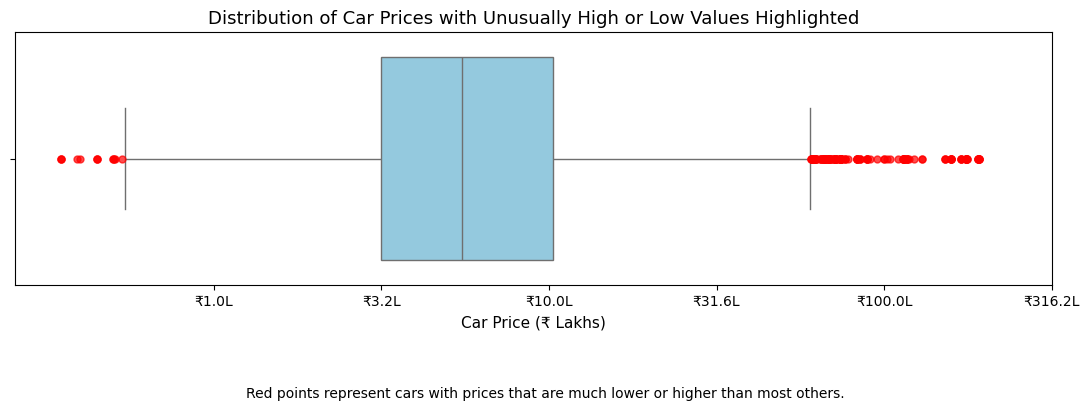

In [24]:
col = df['car_prices_in_rupee'].dropna()
col = col[col > 0]

log_col = np.log10(col)

plt.figure(figsize=(11, 3.5))
ax = sns.boxplot(
    x=log_col,
    color='skyblue',
    flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red', markersize=5, alpha=0.7)
)

plt.title('Distribution of Car Prices with Unusually High or Low Values Highlighted', fontsize=13)
plt.xlabel('Car Price (₹ Lakhs)', fontsize=11)

# Show axis in lakhs instead of log values
tick_values = [5, 5.5, 6, 6.5, 7, 7.5]
tick_labels = [f'₹{10**x/100000:.1f}L' for x in tick_values]
ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels)

# Add a reader-friendly annotation
plt.figtext(
    0.5, -0.15,
    'Red points represent cars with prices that are much lower or higher than most others.',
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()


Lower bound (rupees): 53606.0
Upper bound (rupees): 6027499.0
Number of unusual price listings: 169

All unusual price listings:
                                               car_name             car_model  car_prices_in_rupee  kms_driven fuel_type
                                      Tata Nano Lx BSIV             Tata Nano              35000.0      100000    Petrol
                                         Maruti 800 Std            Maruti 800              35000.0       80000    Petrol
                                           Tata Nano Lx             Tata Nano              35000.0       50000    Petrol
                                         Maruti Zen LXI            Maruti Zen              39000.0      100000    Petrol
                                  Maruti 800 DX 5 Speed            Maruti 800              40000.0       80000    Petrol
                             Tata Indica Xeta GLS BS IV           Tata Indica              45000.0       60000    Petrol
                        

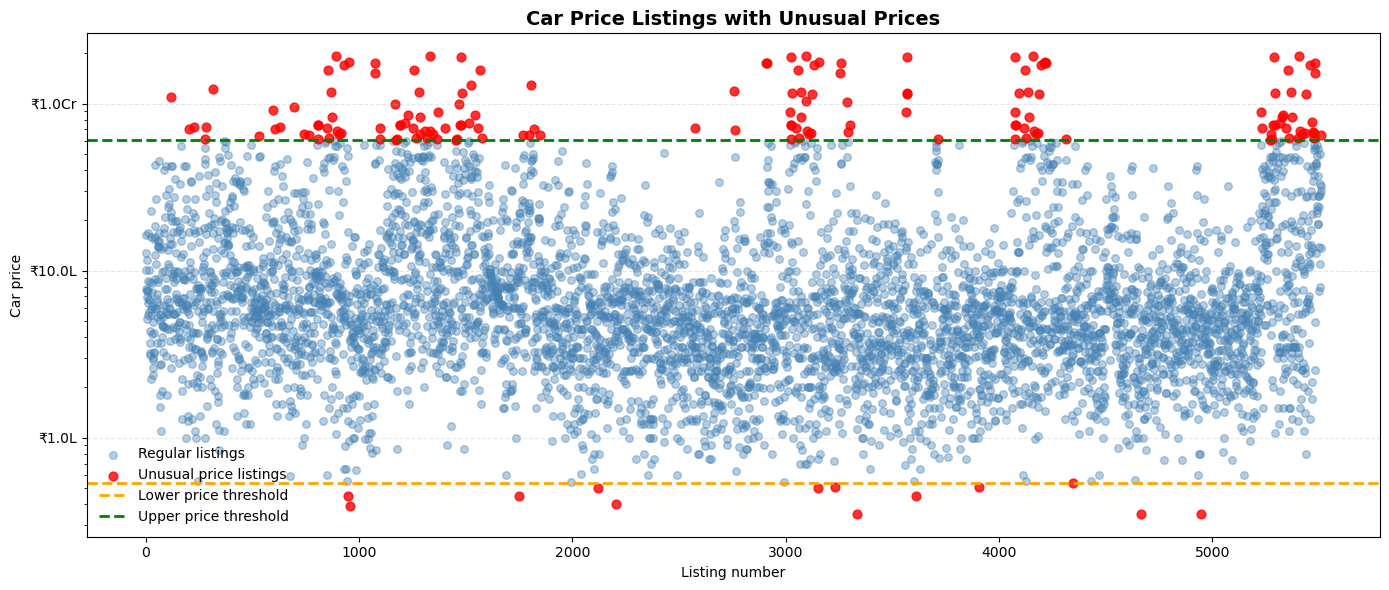

In [25]:
#Data prep
plot_df = df.copy()
plot_df = plot_df[plot_df['car_prices_in_rupee'].notna()].copy()
plot_df = plot_df[plot_df['car_prices_in_rupee'] > 0].copy()
plot_df = plot_df[plot_df['car_name'].notna()].copy()


plot_df['car_model'] = plot_df['car_name'].astype(str).str.split().str[:2].str.join(' ')

#Detect outliers using log scale
plot_df['log_price'] = np.log10(plot_df['car_prices_in_rupee'])

Q1 = plot_df['log_price'].quantile(0.25)
Q3 = plot_df['log_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

plot_df['anomaly'] = (plot_df['log_price'] < lower) | (plot_df['log_price'] > upper)

lower_rupees = 10**lower
upper_rupees = 10**upper

print('Lower bound (rupees):', round(lower_rupees, 0))
print('Upper bound (rupees):', round(upper_rupees, 0))
print('Number of unusual price listings:', int(plot_df['anomaly'].sum()))

#Anomaly car list
cols_to_show = ['car_name', 'car_model', 'car_prices_in_rupee']
extra_cols = ['brand', 'year', 'kms_driven', 'fuel_type']
cols_to_show += [c for c in extra_cols if c in plot_df.columns]

anomalies = plot_df.loc[plot_df['anomaly'], cols_to_show].sort_values('car_prices_in_rupee')

print('\nAll unusual price listings:')
print(anomalies.to_string(index=False))

#Section anomalies
print('\nCheapest unusual listings:')
print(anomalies.head(10).to_string(index=False))

print('\nMost expensive unusual listings:')
print(anomalies.tail(10).to_string(index=False))

#Reset index
plot_df = plot_df.reset_index(drop=True)
x_vals = np.arange(len(plot_df))

#Rupee formatter
def format_inr(x, pos=None):
    if x >= 1e7:
        return f'₹{x/1e7:.1f}Cr'
    elif x >= 1e5:
        return f'₹{x/1e5:.1f}L'
    elif x >= 1e3:
        return f'₹{x/1e3:.0f}K'
    return f'₹{x:.0f}'

#Plot
plt.figure(figsize=(14, 6))

plt.scatter(
    x_vals[~plot_df['anomaly']],
    plot_df.loc[~plot_df['anomaly'], 'car_prices_in_rupee'],
    color='steelblue',
    alpha=0.4,
    s=30,
    label='Regular listings'
)

plt.scatter(
    x_vals[plot_df['anomaly']],
    plot_df.loc[plot_df['anomaly'], 'car_prices_in_rupee'],
    color='red',
    alpha=0.8,
    s=40,
    label='Unusual price listings'
)

plt.axhline(lower_rupees, color='orange', linestyle='--', linewidth=2, label='Lower price threshold')
plt.axhline(upper_rupees, color='green', linestyle='--', linewidth=2, label='Upper price threshold')

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_inr))

plt.title('Car Price Listings with Unusual Prices', fontsize=14, weight='bold')
plt.xlabel('Listing number')
plt.ylabel('Car price')
plt.legend(frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
#drop unnecessary columns
df = df.drop(df.columns[0], axis=1)
df = df.drop(df.columns[0], axis=1)

In [ ]:
#Train/Test Split

In [27]:

df_train, df_test = train_test_split(df, test_size=0.3,
                                     random_state=1234)

In [28]:
X_train = df_train.drop('car_prices_in_rupee', axis=1)
X_test = df_test.drop('car_prices_in_rupee', axis=1)

y_train = df_train['car_prices_in_rupee']
y_test = df_test['car_prices_in_rupee']


In [7]:
#Encoding

In [29]:
cat_cols = ['fuel_type', 'transmission', 'ownership']

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
# Make sure test data has the same columns as training data
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

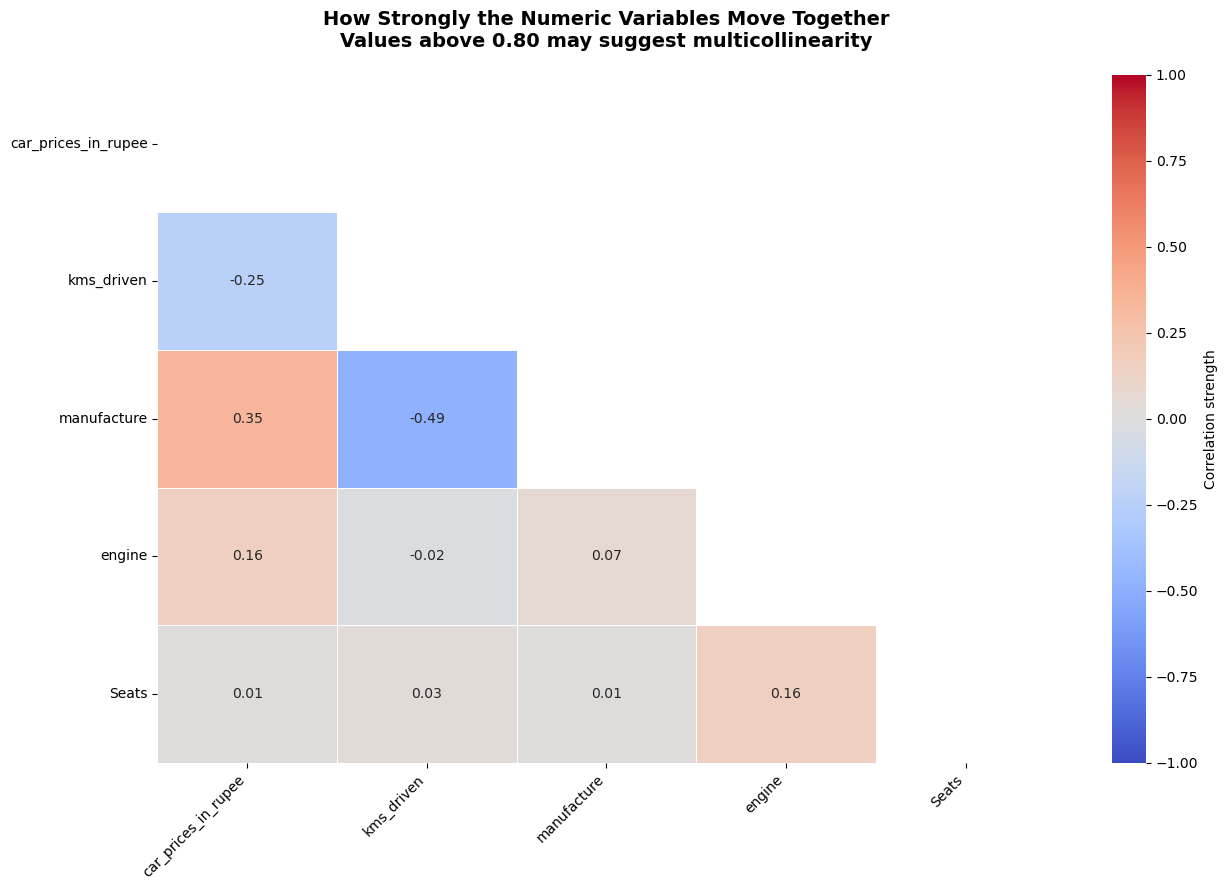

Pairs with correlation above 0.80 (possible multicollinearity):
None found.


In [30]:
#Only numeric columns
num_df = df_train.select_dtypes(include=[np.number])

#Correlation matrix
corr_matrix = num_df.corr()

#Hide upper triangle 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(13, 9))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation strength'}
)

plt.title(
    "How Strongly the Numeric Variables Move Together\n"
    "Values above 0.80 may suggest multicollinearity",
    fontsize=14,
    weight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#Print strong correlations above 0.8
strong_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > 0.8:
            strong_pairs.append((col1, col2, corr_value))

print("Pairs with correlation above 0.80 (possible multicollinearity):")
if strong_pairs:
    for col1, col2, val in strong_pairs:
        print(f"- {col1} and {col2}: {val:.2f}")
else:
    print("None found.")



In [31]:
#Modelling

In [32]:
#Random Forest Model

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
#Prediction for test data
y_pred = rf.predict(X_test)


In [34]:
#Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Random Forest performance on test data:")
print(f"Mean Absolute Error (MAE): ₹{mae:,.0f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:,.0f}")
print(f"R-squared (R²): {r2:.3f}")
print(f"The model explains about {r2:.1%} of the variation in car prices.")


Random Forest performance on test data:
Mean Absolute Error (MAE): ₹532,779
Root Mean Squared Error (RMSE): ₹1,194,290
R-squared (R²): 0.627
The model explains about 62.7% of the variation in car prices.


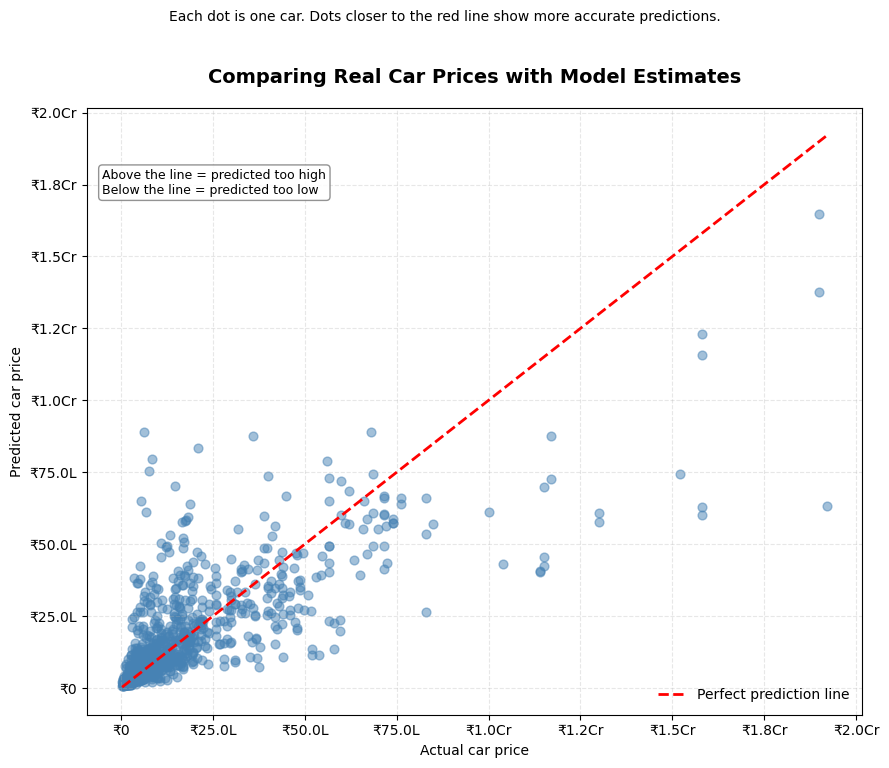

In [40]:
#INR formatter
def format_inr(x, pos=None):
    if x >= 1e7:
        return f'₹{x/1e7:.1f}Cr'
    elif x >= 1e5:
        return f'₹{x/1e5:.1f}L'
    elif x >= 1e3:
        return f'₹{x/1e3:.0f}K'
    return f'₹{x:.0f}'

fig, ax = plt.subplots(figsize=(9, 8))

#Scatter points
ax.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='steelblue',
    s=40
)

#Prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect prediction line'
)

#Main title
ax.set_title('Comparing Real Car Prices with Model Estimates', fontsize=14, weight='bold', pad=18)

#Subtitle
fig.text(
    0.5, 0.94,
    'Each dot is one car. Dots closer to the red line show more accurate predictions.',
    ha='center', fontsize=10
)

#Axis labels
ax.set_xlabel('Actual car price')
ax.set_ylabel('Predicted car price')

#Currency formatting
ax.xaxis.set_major_formatter(FuncFormatter(format_inr))
ax.yaxis.set_major_formatter(FuncFormatter(format_inr))

#Note box 
ax.text(
    0.02, 0.90,
    'Above the line = predicted too high\nBelow the line = predicted too low',
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray')
)

ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.3, linestyle='--')

# Leave room for subtitle
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


In [36]:
#Input importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(15))


                Feature  Importance
0            kms_driven    0.311529
8   transmission_Manual    0.282052
1           manufacture    0.164706
2                engine    0.153421
4      fuel_type_Diesel    0.032895
3                 Seats    0.024756
9   ownership_1st Owner    0.012185
10  ownership_2nd Owner    0.009499
7      fuel_type_Petrol    0.006745
11  ownership_3rd Owner    0.001432
5    fuel_type_Electric    0.000512
12  ownership_4th Owner    0.000264
6         fuel_type_Lpg    0.000004
13  ownership_5th Owner    0.000001
